# Willingness-to-Pay Estimation and Bundle Pricing Decisions

## Scenario
A pricing team needs to understand how much customers would pay for specific
subscription features. Using the part-worth utilities you estimated from conjoint data,
you will derive **directional willingness-to-pay (WTP)** for key features and score
candidate bundles to recommend a launch configuration.

## Your task
You will produce:
1. Directional WTP estimates (in USD/month) for at least **two features**
   using the coefficient ratio method: WTP = -β_feature / β_price
2. A scored/ranked table of candidate bundles from `candidate_bundles.csv`
3. A stated bundle recommendation with pricing rationale
4. A short assumptions/limitations checklist

## Requirements
- Refit the conjoint logistic model from `choice_conjoint_tasks.csv`
- WTP computation must show the numeric result and formula explicitly
- Bundle scoring uses `model.predict_proba` on features from `candidate_bundles.csv`
- Recommendation must name a specific bundle and reference WTP evidence

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [3]:
# ── Step 1: Refit the conjoint model ──────────────────────────────────────
df = pd.read_csv(CHOICE_PATH)

# Encode and prepare features (same setup as part-worth exercise)
df_enc = pd.get_dummies(df, columns=['support','ads','offline_download'], drop_first=False)
df_enc.drop(columns=['support_Standard','ads_Ads','offline_download_No'], inplace=True)
feat_cols = ['price_usd','storage_gb','family_seats',
             'support_Priority','ads_NoAds','offline_download_Yes']
X = df_enc[feat_cols].astype(float)
y = df_enc['chosen']

model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X, y)
partworths = pd.Series(model.coef_[0], index=feat_cols)
print("Part-worths:", partworths.round(4).to_dict())

Part-worths: {'price_usd': -0.3572, 'storage_gb': 0.0024, 'family_seats': 0.1571, 'support_Priority': 0.493, 'ads_NoAds': 0.8188, 'offline_download_Yes': 0.2913}


In [4]:
# ── Step 2: Compute directional WTP for key features ──────────────────────
# WTP = -beta_feature / beta_price  (price coefficient is negative, so result is positive for desired features)
beta_price = partworths['price_usd']

wtp_noads    = -partworths['ads_NoAds']              / beta_price
wtp_priority = -partworths['support_Priority']       / beta_price
wtp_offline  = -partworths['offline_download_Yes']   / beta_price

print(f"WTP for No Ads (vs Ads):            ${wtp_noads:.2f}/month")
print(f"WTP for Priority Support (vs Std):  ${wtp_priority:.2f}/month")
print(f"WTP for Offline Downloads:          ${wtp_offline:.2f}/month")
print()
print("Note: WTP is directional; treat as a pricing anchor, not a precise ceiling.")

WTP for No Ads (vs Ads):            $2.29/month
WTP for Priority Support (vs Std):  $1.38/month
WTP for Offline Downloads:          $0.82/month

Note: WTP is directional; treat as a pricing anchor, not a precise ceiling.


In [5]:
# ── Step 3: Score and rank candidate bundles ──────────────────────────────
bundles = pd.read_csv(BUNDLES_PATH)

# Re-encode bundle features to match training feature space
b = bundles.copy()
b['support_Priority']      = (b['support']           == 'Priority').astype(int)
b['ads_NoAds']             = (b['ads']               == 'NoAds').astype(int)
b['offline_download_Yes']  = (b['offline_download']  == 'Yes').astype(int)

X_bundles = b[feat_cols].astype(float)

# Score bundles using the fitted model
bundles['score'] = model.predict_proba(X_bundles)[:, 1]
bundle_ranking = bundles[['bundle','price_usd','score']].sort_values('score', ascending=False)
print("Bundle ranking (higher score = higher predicted choice probability):")
bundle_ranking

Bundle ranking (higher score = higher predicted choice probability):


,bundle,price_usd,score
2,Premium,15,0.414925
1,Mid,8,0.369095
0,Budget,5,0.197898
3,ValuePlus,12,0.186649


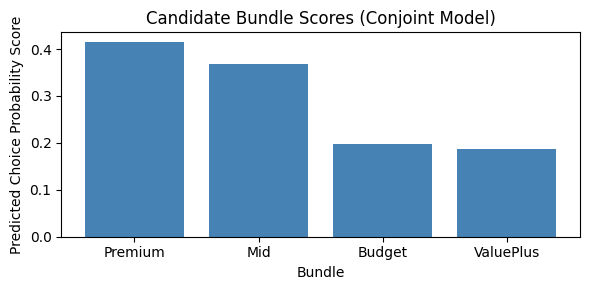

In [6]:
# ── Step 4: Bundle recommendation + bar chart ─────────────────────────────
# Visualize bundle scores for comparison
plt.figure(figsize=(6, 3))
plt.bar(bundle_ranking['bundle'], bundle_ranking['score'], color='steelblue')
plt.xlabel("Bundle")
plt.ylabel("Predicted Choice Probability Score")
plt.title("Candidate Bundle Scores (Conjoint Model)")
plt.tight_layout()
plt.show()

## Recommendation and Limitations

In the markdown cell below, write:
1. **Recommended bundle**: name the top-scoring bundle and state why (reference the score and WTP values)
2. **Pricing rationale**: use at least one WTP value to justify the recommended price point
3. **Assumptions/Limitations** (checklist format):
   - [ ] WTP is derived from a choice model, not direct elicitation
   - [ ] Price coefficient assumed constant across customer segments
   - [ ] ...add at least one more assumption or limitation

In [7]:
# Print recommendation summary for reference
top_bundle = bundle_ranking.iloc[0]
print(f"Recommended bundle: {top_bundle['bundle']}")
print(f"  Score: {top_bundle['score']:.4f}")
print(f"  Price: ${top_bundle['price_usd']}/month")
print()
print("Pricing rationale:")
print(f"  No Ads WTP ≈ ${wtp_noads:.2f} → customers willing to pay ~${wtp_noads:.2f} above base price for ad-free")
print()
print("Assumptions/Limitations:")
print("  - WTP is directional; derived from model, not direct measurement")
print("  - Price coefficient assumed linear and homogeneous across all segments")
print("  - Model treats each choice as independent (ignores within-respondent correlation)")

Recommended bundle: Premium
  Score: 0.4149
  Price: $15/month

Pricing rationale:
  No Ads WTP ≈ $2.29 → customers willing to pay ~$2.29 above base price for ad-free

Assumptions/Limitations:
  - WTP is directional; derived from model, not direct measurement
  - Price coefficient assumed linear and homogeneous across all segments
  - Model treats each choice as independent (ignores within-respondent correlation)
